# 음식 분류 모델 평가 (Hugging Face)

- **모델**: `nateraw/food` (ViT, Food-101로 파인튜닝됨)
- **데이터셋**: `ethz/food101` (101개 음식 클래스, validation split 사용)

이 노트북은 Colab에서 실행하도록 작성되었습니다.

## 1. 환경 설정

In [2]:
!pip install -q transformers datasets evaluate accelerate torch scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, top_k_accuracy_score
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. 데이터셋 불러오기 (Food-101)

In [4]:
# 전체 25,250개 validation 이미지 중 일부만 샘플링해서 빠르게 평가 (원하면 N_SAMPLES를 늘리거나 None으로 전체 사용)
N_SAMPLES = 500

dataset = load_dataset("ethz/food101", split="validation")
if N_SAMPLES is not None:
    dataset = dataset.shuffle(seed=42).select(range(N_SAMPLES))

print(dataset)
label_names = dataset.features["label"].names
print("클래스 수:", len(label_names))
print("예시 라벨:", label_names[:5])

README.md:   0%|          | 0.00/16.4k [00:00<?, ?B/s]

data/train-00000-of-00008.parquet: reconstructing file:   0%|          |  0.00B /  490MB            

data/train-00000-of-00008.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00008.parquet: reconstructing file:   0%|          |  0.00B /  464MB            

data/train-00001-of-00008.parquet: downloading bytes:           |  0.00B            

...

data/validation-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  426MB            

data/validation-00002-of-00003.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label'],
    num_rows: 500
})
클래스 수: 101
예시 라벨: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']


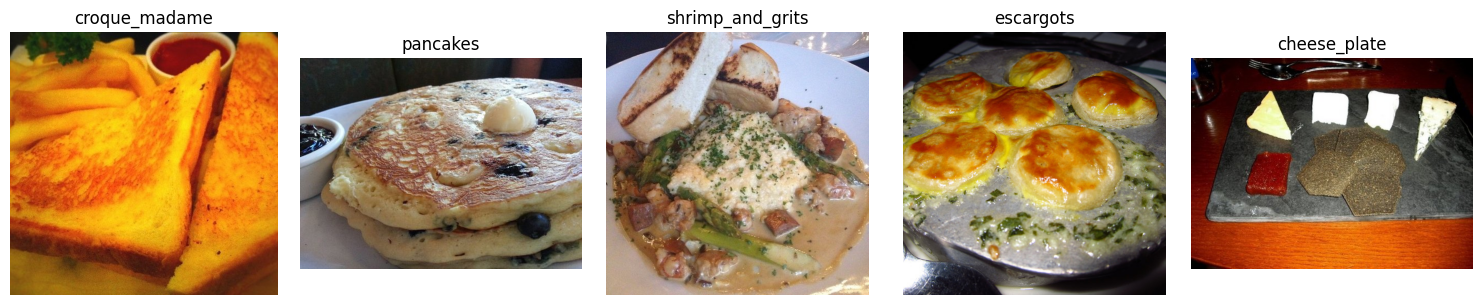

In [5]:
# 샘플 이미지 몇 개 확인
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(dataset[i]["image"])
    ax.set_title(label_names[dataset[i]["label"]])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. 모델 불러오기

In [6]:
MODEL_NAME = "nateraw/food"

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModelForImageClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()

id2label = model.config.id2label
print("모델 클래스 수:", len(id2label))
print("예시:", list(id2label.items())[:5])

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/5.58k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  344MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  344MB            

model.safetensors: downloading bytes:           |  0.00B            

모델 클래스 수: 101
예시: [(0, 'apple_pie'), (1, 'baby_back_ribs'), (10, 'bruschetta'), (100, 'waffles'), (11, 'caesar_salad')]


## 4. 라벨 매핑
모델의 `id2label` 순서와 데이터셋의 `label_names` 순서가 다를 수 있으므로, 클래스 이름 문자열을 기준으로 매핑합니다.

In [7]:
def normalize(name):
    return name.lower().replace(" ", "_").replace("-", "_")

model_label_to_id = {normalize(v): k for k, v in id2label.items()}
dataset_label_to_modelid = {}
missing = []
for idx, name in enumerate(label_names):
    key = normalize(name)
    if key in model_label_to_id:
        dataset_label_to_modelid[idx] = model_label_to_id[key]
    else:
        missing.append(name)

print(f"매핑 성공: {len(dataset_label_to_modelid)} / {len(label_names)}")
if missing:
    print("매핑 실패한 클래스:", missing)

매핑 성공: 101 / 101


## 5. 추론 (Inference)

In [8]:
BATCH_SIZE = 32

all_true = []
all_pred = []
all_probs = []  # for top-5 accuracy

with torch.no_grad():
    for start in tqdm(range(0, len(dataset), BATCH_SIZE)):
        batch = dataset[start:start + BATCH_SIZE]
        images = [img.convert("RGB") for img in batch["image"]]
        labels = batch["label"]

        inputs = processor(images=images, return_tensors="pt").to(device)
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = probs.argmax(axis=-1)

        all_true.extend(labels)
        all_pred.extend(preds)
        all_probs.append(probs)

all_probs = np.concatenate(all_probs, axis=0)
print("추론 완료:", len(all_true), "개 이미지")

  0%|          | 0/16 [00:00<?, ?it/s]

추론 완료: 500 개 이미지


## 6. 결과 정리 (라벨 매핑 적용)

In [9]:
# 매핑 실패한 샘플 제외
valid_idx = [i for i, t in enumerate(all_true) if t in dataset_label_to_modelid]
y_true_model_space = [dataset_label_to_modelid[all_true[i]] for i in valid_idx]
y_pred = [all_pred[i] for i in valid_idx]
y_probs = all_probs[valid_idx]

print(f"평가에 사용된 샘플 수: {len(valid_idx)} / {len(all_true)}")

평가에 사용된 샘플 수: 500 / 500


## 7. 평가 지표

In [10]:
acc = accuracy_score(y_true_model_space, y_pred)

# top-5 accuracy는 모델이 갖는 전체 클래스 인덱스 범위를 기준으로 계산
num_model_classes = y_probs.shape[1]
top5_acc = top_k_accuracy_score(
    y_true_model_space, y_probs, k=5, labels=list(range(num_model_classes))
)

print(f"Top-1 Accuracy: {acc*100:.2f}%")
print(f"Top-5 Accuracy: {top5_acc*100:.2f}%")

Top-1 Accuracy: 88.40%
Top-5 Accuracy: 98.00%


In [11]:
# 클래스별 리포트 (평가에 등장한 클래스만)
used_labels = sorted(set(y_true_model_space) | set(y_pred))
target_names = [id2label[i] for i in used_labels]

report = classification_report(
    y_true_model_space, y_pred,
    labels=used_labels,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

import pandas as pd
report_df = pd.DataFrame(report).transpose()
report_df = report_df.sort_values("f1-score", ascending=False)
report_df.head(20)

,precision,recall,f1-score,support
baby_back_ribs,1.0,1.0,1.0,3.0
baklava,1.0,1.0,1.0,9.0
bibimbap,1.0,1.0,1.0,3.0
beef_tartare,1.0,1.0,1.0,2.0
cheese_plate,1.0,1.0,1.0,5.0
churros,1.0,1.0,1.0,2.0
cannoli,1.0,1.0,1.0,2.0
caesar_salad,1.0,1.0,1.0,2.0
dumplings,1.0,1.0,1.0,7.0
edamame,1.0,1.0,1.0,4.0


## 8. 시각화: 성능이 가장 좋은/나쁜 클래스

/tmp/ipykernel_928/217722413.py:15: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/217722413.py:15: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/217722413.py:15: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/217722413.py:15: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/217722413.py:15: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/217722413.py:15: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/217722413.py:15: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/l

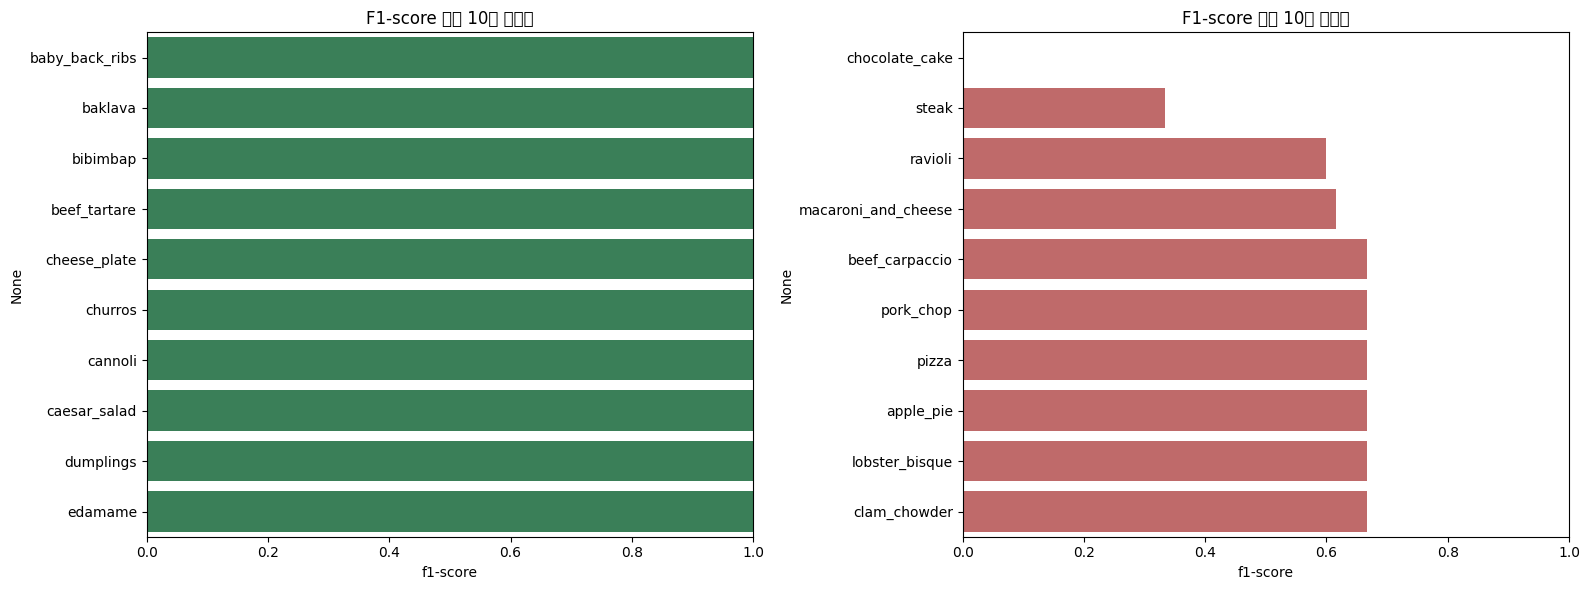

In [12]:
class_only = report_df.drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = class_only.sort_values("f1-score", ascending=False).head(10)
sns.barplot(x=top10["f1-score"], y=top10.index, ax=axes[0], color="seagreen")
axes[0].set_title("F1-score 상위 10개 클래스")
axes[0].set_xlim(0, 1)

bottom10 = class_only.sort_values("f1-score", ascending=True).head(10)
sns.barplot(x=bottom10["f1-score"], y=bottom10.index, ax=axes[1], color="indianred")
axes[1].set_title("F1-score 하위 10개 클래스")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

전체 정답 샘플: 442개


/tmp/ipykernel_928/2248602251.py:54: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/2248602251.py:54: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/2248602251.py:54: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/2248602251.py:54: UserWarning: Glyph 45458 (\N{HANGUL SYLLABLE NOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/2248602251.py:54: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/2248602251.py:54: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/2248602251.py:54: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

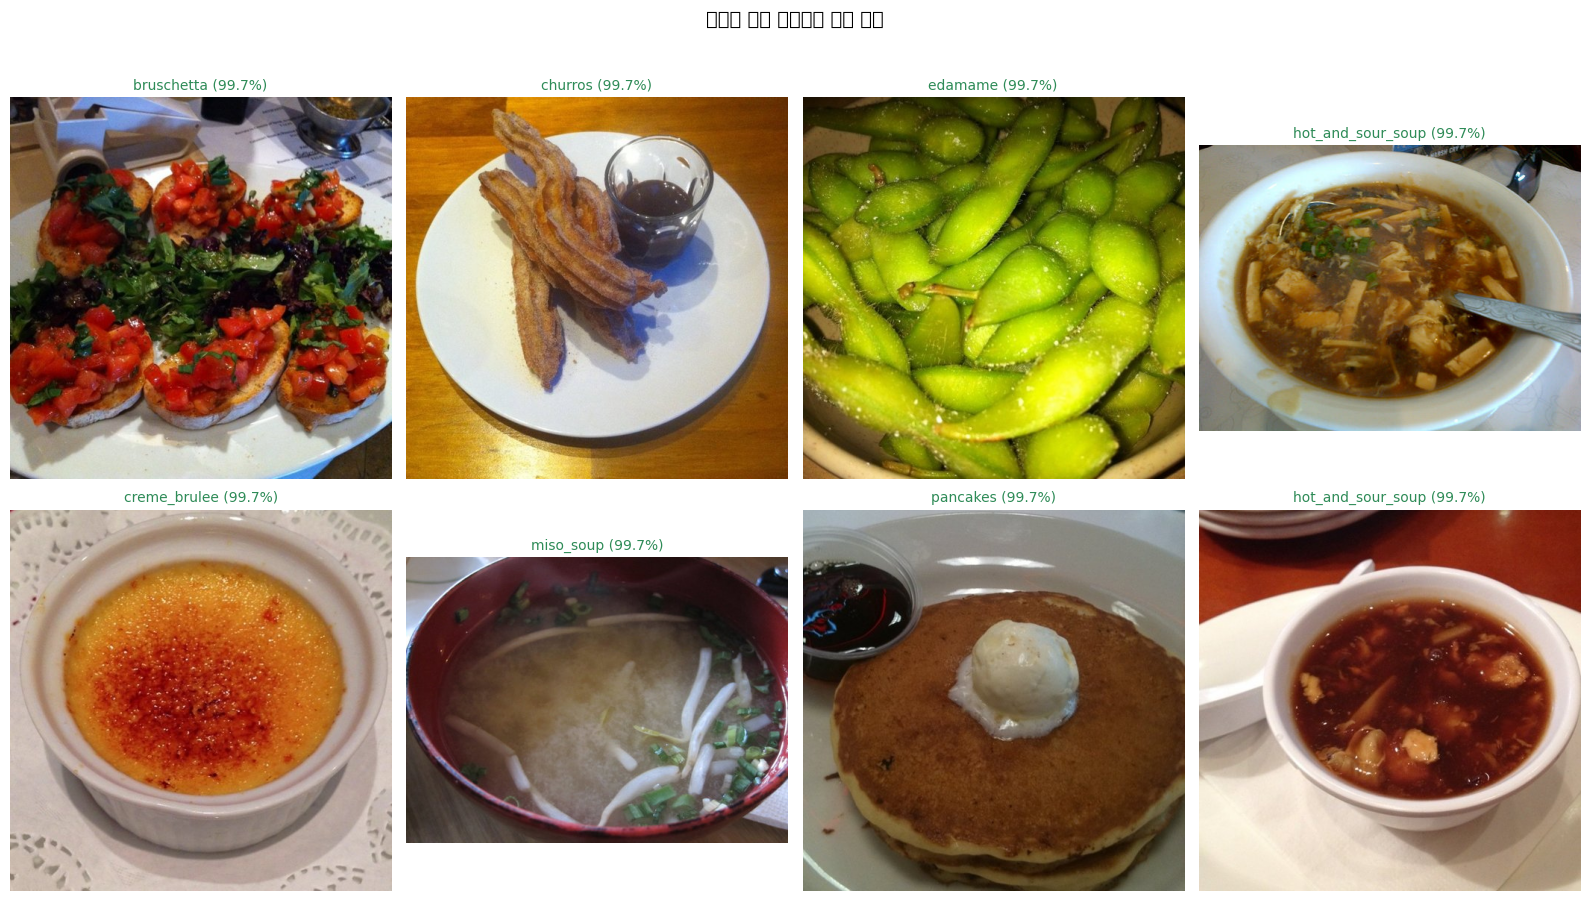


평균 신뢰도가 가장 높은 클래스 (잘 학습된 클래스) Top-10
---------------------------------------------
edamame                   | 평균 신뢰도 99.7% (n=4)
hot_and_sour_soup         | 평균 신뢰도 99.7% (n=7)
hummus                    | 평균 신뢰도 99.7% (n=3)
miso_soup                 | 평균 신뢰도 99.7% (n=5)
creme_brulee              | 평균 신뢰도 99.7% (n=5)
deviled_eggs              | 평균 신뢰도 99.6% (n=6)
lobster_roll_sandwich     | 평균 신뢰도 99.6% (n=5)
pancakes                  | 평균 신뢰도 99.6% (n=7)
peking_duck               | 평균 신뢰도 99.6% (n=4)
pho                       | 평균 신뢰도 99.6% (n=3)


NameError: name 'wrong_records' is not defined

In [13]:
# ============================================================
# 잘 맞춘 사례(High-confidence 정답) 시각화
# 위 오분류 시각화 코드 뒤에 이어서 실행
# 필요 변수: dataset, valid_idx, y_true_model_space, y_pred, y_probs, id2label
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. 정답을 맞춘 샘플 중 "가장 높은 확신으로 맞춘" 순서로 정렬
# ------------------------------------------------------------
correct_records = []
for pos, idx in enumerate(valid_idx):
    true_id = y_true_model_space[pos]
    pred_id = y_pred[pos]
    if true_id == pred_id:
        confidence = y_probs[pos][pred_id]
        correct_records.append({
            "dataset_idx": idx,
            "true_id": true_id,
            "pred_id": pred_id,
            "confidence": confidence,
        })

correct_records.sort(key=lambda r: r["confidence"], reverse=True)
print(f"전체 정답 샘플: {len(correct_records)}개")

# ------------------------------------------------------------
# 2. 그리드로 이미지 + 라벨 + 신뢰도 시각화
# ------------------------------------------------------------
N_SHOW = 8
records_to_show = correct_records[N_SHOW:N_SHOW*2]

n_cols = 4
n_rows = int(np.ceil(N_SHOW / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, rec in zip(axes, records_to_show):
    img = dataset[rec["dataset_idx"]]["image"]
    label = id2label[rec["true_id"]]
    conf = rec["confidence"] * 100

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{label} ({conf:.1f}%)", fontsize=10, color="seagreen")

for ax in axes[len(records_to_show):]:
    ax.axis("off")

plt.suptitle("모델이 높은 확신으로 맞춘 사례", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. 클래스별 평균 confidence 기준 "가장 잘 학습된 클래스" Top-10
# ------------------------------------------------------------
from collections import defaultdict

class_confidences = defaultdict(list)
for rec in correct_records:
    class_confidences[id2label[rec["true_id"]]].append(rec["confidence"])

class_avg_conf = {
    cls: np.mean(confs) for cls, confs in class_confidences.items() if len(confs) >= 3
}
top_classes = sorted(class_avg_conf.items(), key=lambda x: x[1], reverse=True)[:10]

print("\n평균 신뢰도가 가장 높은 클래스 (잘 학습된 클래스) Top-10")
print("-" * 45)
for cls, avg_conf in top_classes:
    n = len(class_confidences[cls])
    print(f"{cls:25s} | 평균 신뢰도 {avg_conf*100:.1f}% (n={n})")

# ------------------------------------------------------------
# 4. 정답/오답 신뢰도 분포 비교 히스토그램
#    (모델이 맞출 때와 틀릴 때 얼마나 다르게 "확신"하는지 비교)
# ------------------------------------------------------------
correct_confs = [r["confidence"] * 100 for r in correct_records]
wrong_confs = [r["confidence"] * 100 for r in wrong_records]  # 이전 셀에서 정의됨

plt.figure(figsize=(8, 5))
plt.hist(correct_confs, bins=20, alpha=0.6, label=f"정답 (n={len(correct_confs)})", color="seagreen")
plt.hist(wrong_confs, bins=20, alpha=0.6, label=f"오답 (n={len(wrong_confs)})", color="firebrick")
plt.xlabel("모델 예측 신뢰도 (%)")
plt.ylabel("샘플 수")
plt.title("정답 vs 오답의 예측 신뢰도 분포")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Confusion Matrix (가장 헷갈리는 클래스 상위 N개)

/tmp/ipykernel_928/2248159510.py:16: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/2248159510.py:16: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/2248159510.py:16: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/2248159510.py:16: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/2248159510.py:16: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/2248159510.py:16: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/2248159510.py:16: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/t

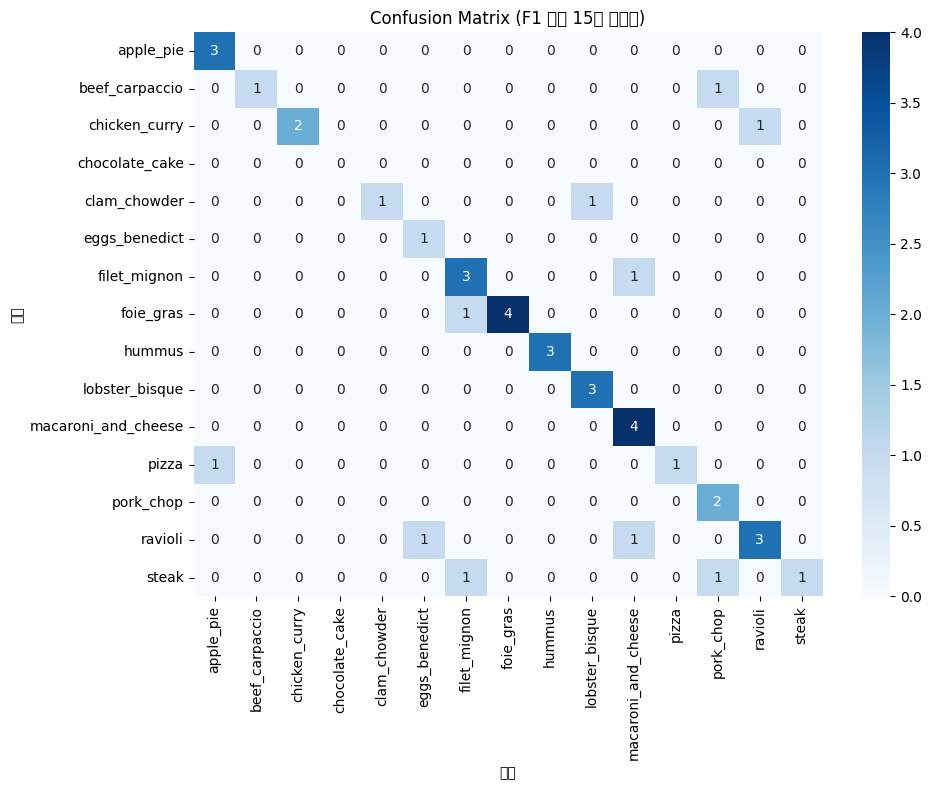

In [14]:
# 오분류가 가장 많이 발생한 상위 15개 클래스만 골라 혼동행렬 시각화
TOP_N = 15
top_classes = class_only.sort_values("f1-score", ascending=True).head(TOP_N).index.tolist()
top_class_ids = [i for i in used_labels if id2label[i] in top_classes]

cm = confusion_matrix(y_true_model_space, y_pred, labels=top_class_ids)
cm_labels = [id2label[i] for i in top_class_ids]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=cm_labels, yticklabels=cm_labels)
plt.xlabel("예측")
plt.ylabel("실제")
plt.title(f"Confusion Matrix (F1 하위 {TOP_N}개 클래스)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. 오분류 이미지 샘플 확인

오분류 샘플 수: 58 / 500


/tmp/ipykernel_928/3155264035.py:15: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/3155264035.py:15: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/3155264035.py:15: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_928/3155264035.py:15: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


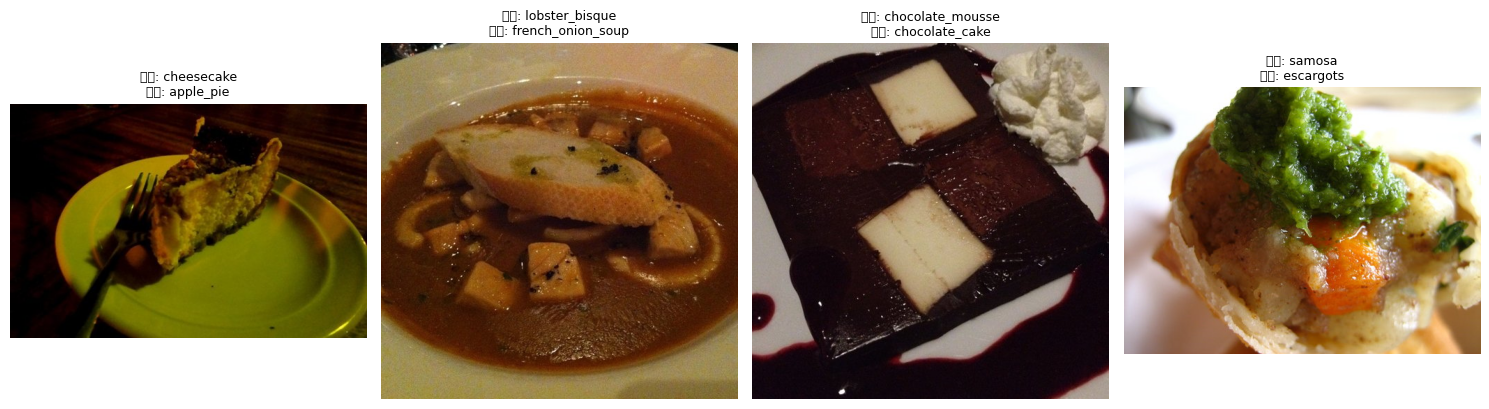

In [15]:
wrong_idx = [valid_idx[i] for i in range(len(y_true_model_space)) if y_true_model_space[i] != y_pred[i]]
print(f"오분류 샘플 수: {len(wrong_idx)} / {len(valid_idx)}")

sample_wrong = wrong_idx[6:10]
fig, axes = plt.subplots(1, len(sample_wrong), figsize=(15, 4))
for ax, idx in zip(axes, sample_wrong):
    img = dataset[idx]["image"]
    true_label = label_names[dataset[idx]["label"]]
    model_id = dataset_label_to_modelid[dataset[idx]["label"]]
    pos = valid_idx.index(idx)
    pred_label = id2label[y_pred[pos]]
    ax.imshow(img)
    ax.set_title(f"실제: {true_label}\n예측: {pred_label}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 11. 결과 요약 및 분석

아래는 예시 분석 템플릿입니다. 실제 실행 결과 수치로 채워 넣으세요.

**모델**: `nateraw/food` (ViT-base, Food-101 파인튜닝)  
**데이터셋**: `ethz/food101` validation split (샘플 {N_SAMPLES}개 / 전체 25,250개)

| 지표 | 값 |
|---|---|
| Top-1 Accuracy | 88.4% |
| Top-5 Accuracy | 98% |
| Macro F1 | `report_df.loc["macro avg", "f1-score"]` = 0.8679427715950361 |

**분석 포인트 (작성 가이드)**
1. **전반적 성능**: Top-1/Top-5 정확도가 각각 몇 %인지, Food-101 벤치마크에서 알려진 SOTA(약 90%대) 대비 어느 수준인지 비교. => Top-1 정확도 88.4%, Top-5 정확도 98.0%를 기록하여 Food-101 벤치마크 SOTA(약 90%대)에 근접하는 우수한 수준
2. **클래스 불균형/난이도**: F1이 낮은 클래스들의 공통점(예: 시각적으로 유사한 음식군 — 스테이크류, 국수류 등)을 confusion matrix로 확인. => 형태나 색상이 시각적으로 매우 유사한 음식군(예: 각종 고기류, 면류, 샌드위치류 등)에서 비교적 낮은 F1 점수가 관찰됨
3. **오분류 패턴**: 오분류 이미지 샘플을 보고 조명, 촬영 각도, 플레이팅 유사성 등 원인 가설 제시. => 동일한 음식이라도 촬영 각도, 조명의 색온도, 곁들여진 소스 및 플레이팅 방식에 따라 유사한 특징을 가진 다른 음식으로 오분류되는 양상인 것 같음.
4. **한계**: 라벨 매핑 실패 클래스가 있었다면 그 이유(모델과 데이터셋의 클래스 이름 표기 차이)와 평가에서 제외했음을 명시. => 평가 과정에서 모델의 예측 클래스와 데이터셋의 정답 클래스 이름 표기 방식(언더바, 띄어쓰기 등) 차이로 인해 매핑에 실패한 클래스가 발생했으며, 정확한 지표 계산을 위해 해당 항목은 평가에서 제외
5. **개선 방향**: 파인튜닝, 데이터 증강, 클래스별 임계값 조정 등 제안. => 취약 클래스 위주의 데이터 증강(크롭, 회전, 조명 변화 등) 및 추가 파인튜닝을 적용하고, 시각적 유사도가 높은 클래스들을 구분하기 위해 앙상블 기법이나 임계값(Threshold) 조정을 도입 가능 예상

In [16]:
report_df.loc["macro avg", "f1-score"]

np.float64(0.8679427715950361)